In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [11]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

HEADERS = {"User-Agent": "Your Name your.email@example.com"}  # use your real details
CIK = "0000320193"  # Apple Inc.

In [12]:
url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{CIK}.json"
resp = requests.get(url, headers=HEADERS, timeout=30)
resp.raise_for_status()
facts = resp.json()["facts"]["us-gaap"]
print(f"Loaded {len(facts)} financial tags")

Loaded 503 financial tags


In [13]:
STATEMENTS = {
    "Income Statement": {
        "Revenue": (["RevenueFromContractWithCustomerExcludingAssessedTax", "SalesRevenueNet"], "USD"),
        "Cost of Sales": (["CostOfGoodsAndServicesSold", "CostOfRevenue"], "USD"),
        "Gross Profit": (["GrossProfit"], "USD"),
        "R&D Expense": (["ResearchAndDevelopmentExpense"], "USD"),
        "Operating Income": (["OperatingIncomeLoss"], "USD"),
        "Net Income": (["NetIncomeLoss"], "USD"),
        "Diluted EPS": (["EarningsPerShareDiluted"], "USD/shares"),
    },
    "Balance Sheet": {
        "Cash & Equivalents": (["CashAndCashEquivalentsAtCarryingValue"], "USD"),
        "Total Assets": (["Assets"], "USD"),
        "Total Liabilities": (["Liabilities"], "USD"),
        "Shareholders' Equity": (["StockholdersEquity"], "USD"),
    },
    "Cash Flow": {
        "Operating Cash Flow": (["NetCashProvidedByUsedInOperatingActivities"], "USD"),
        "CapEx": (["PaymentsToAcquirePropertyPlantAndEquipment"], "USD"),
    },
}

In [14]:
def extract_annual(facts, tags, unit):
    """Return a Series of annual (10-K) values indexed by fiscal year."""
    rows = []
    for tag in tags:
        if tag not in facts:
            continue
        for f in facts[tag]["units"].get(unit, []):
            if f.get("form") != "10-K":
                continue
            # For income/cash-flow items, keep only full-year periods
            if "start" in f:
                days = (pd.to_datetime(f["end"]) - pd.to_datetime(f["start"])).days
                if not 340 <= days <= 380:
                    continue
            rows.append({"end": f["end"], "value": f["val"], "filed": f["filed"]})

    if not rows:
        return pd.Series(dtype=float)

    df = pd.DataFrame(rows).sort_values("filed").drop_duplicates("end", keep="last")
    df["year"] = pd.to_datetime(df["end"]).dt.year
    return df.set_index("year")["value"].sort_index()


def build_statement(facts, items):
    data = {name: extract_annual(facts, tags, unit) for name, (tags, unit) in items.items()}
    return pd.DataFrame(data).T.sort_index(axis=1)


income = build_statement(facts, STATEMENTS["Income Statement"])
balance = build_statement(facts, STATEMENTS["Balance Sheet"])
cashflow = build_statement(facts, STATEMENTS["Cash Flow"])

# Show the last 5 years, in $ millions (EPS left as-is)
def show(df, years=5):
    out = df.iloc[:, -years:].copy()
    money = out.index != "Diluted EPS"
    out.loc[money] = out.loc[money] / 1e6
    return out.round(2)

from IPython.display import display

display(show(income))
display(show(balance))
display(show(cashflow))

rev = income.loc["Revenue"]
ratios = pd.DataFrame({
    "Revenue Growth %": rev.pct_change() * 100,
    "Gross Margin %": income.loc["Gross Profit"] / rev * 100,
    "Operating Margin %": income.loc["Operating Income"] / rev * 100,
    "Net Margin %": income.loc["Net Income"] / rev * 100,
    "ROE %": income.loc["Net Income"] / balance.loc["Shareholders' Equity"] * 100,
    "Free Cash Flow ($M)": (cashflow.loc["Operating Cash Flow"] - cashflow.loc["CapEx"]) / 1e6,
}).T.sort_index(axis=1)

ratios.iloc[:, -5:].round(1)

year,2021,2022,2023,2024,2025
Revenue,365817.00,394328.00,383285.00,391035.00,416161.00
Cost of Sales,212981.00,223546.00,214137.00,210352.00,220960.00
Gross Profit,152836.00,170782.00,169148.00,180683.00,195201.00
R&D Expense,21914.00,26251.00,29915.00,31370.00,34550.00
Operating Income,108949.00,119437.00,114301.00,123216.00,133050.00
Net Income,94680.00,99803.00,96995.00,93736.00,112010.00
Diluted EPS,5.61,6.11,6.13,6.08,7.46


year,2021,2022,2023,2024,2025
Cash & Equivalents,34940.0,23646.0,29965.0,29943.0,35934.0
Total Assets,351002.0,352755.0,352583.0,364980.0,359241.0
Total Liabilities,287912.0,302083.0,290437.0,308030.0,285508.0
Shareholders' Equity,63090.0,50672.0,62146.0,56950.0,73733.0


year,2021,2022,2023,2024,2025
Operating Cash Flow,104038.0,122151.0,110543.0,118254.0,111482.0
CapEx,11085.0,10708.0,10959.0,9447.0,12715.0


year,2021,2022,2023,2024,2025
Revenue Growth %,33.3,7.8,-2.8,2.0,6.4
Gross Margin %,41.8,43.3,44.1,46.2,46.9
Operating Margin %,29.8,30.3,29.8,31.5,32.0
Net Margin %,25.9,25.3,25.3,24.0,26.9
ROE %,150.1,197.0,156.1,164.6,151.9
Free Cash Flow ($M),92953.0,111443.0,99584.0,108807.0,98767.0


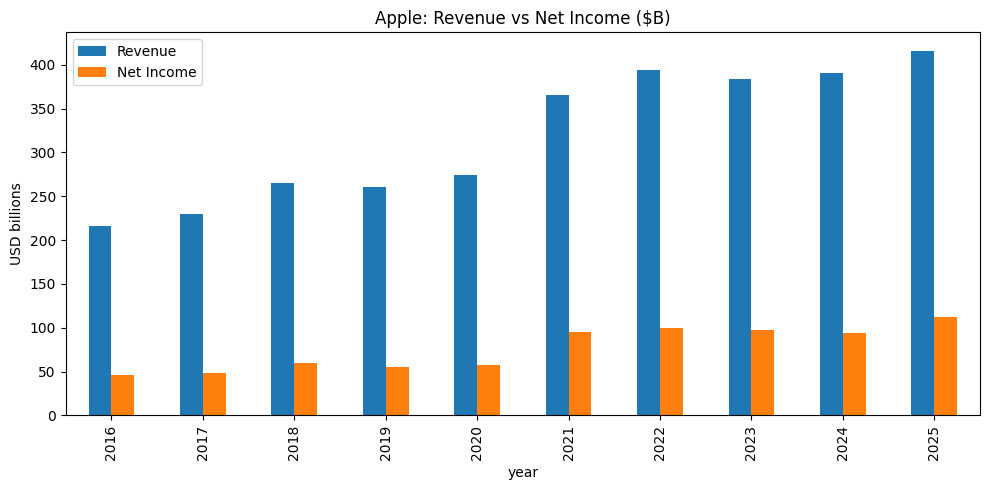

In [15]:
ratios.iloc[:, -5:].round(1)
(income.loc[["Revenue", "Net Income"]].iloc[:, -10:] / 1e9).T.plot(kind="bar", figsize=(10, 5))
plt.title("Apple: Revenue vs Net Income ($B)")
plt.ylabel("USD billions")
plt.tight_layout()
plt.savefig("apple_revenue_vs_income.png", dpi=150)
plt.show()

income.to_csv("apple_income_statement.csv")
balance.to_csv("apple_balance_sheet.csv")
cashflow.to_csv("apple_cash_flow.csv")
ratios.to_csv("apple_ratios.csv")

In [16]:
# ---- Analysis, Cell A: extra data + metrics ----
EXTRA = {
    "Current Assets": (["AssetsCurrent"], "USD"),
    "Current Liabilities": (["LiabilitiesCurrent"], "USD"),
    "Long-Term Debt": (["LongTermDebtNoncurrent"], "USD"),
    "Diluted Shares": (["WeightedAverageNumberOfDilutedSharesOutstanding"], "shares"),
    "Share Buybacks": (["PaymentsForRepurchaseOfCommonStock"], "USD"),
}
extra = build_statement(facts, EXTRA)

# One table: rows = years, columns = every line item (raw USD)
d = pd.concat([income, balance, cashflow, extra]).T.sort_index()

m = pd.DataFrame(index=d.index)
fcf = d["Operating Cash Flow"] - d["CapEx"]

# Growth
m["Revenue Growth %"] = d["Revenue"].pct_change(fill_method=None) * 100
m["EPS Growth %"] = d["Diluted EPS"].pct_change(fill_method=None) * 100
# Profitability
m["Gross Margin %"] = d["Gross Profit"] / d["Revenue"] * 100
m["Operating Margin %"] = d["Operating Income"] / d["Revenue"] * 100
m["Net Margin %"] = d["Net Income"] / d["Revenue"] * 100
m["R&D % of Revenue"] = d["R&D Expense"] / d["Revenue"] * 100
m["ROE %"] = d["Net Income"] / d["Shareholders' Equity"] * 100
m["ROA %"] = d["Net Income"] / d["Total Assets"] * 100
# Liquidity and leverage
m["Current Ratio"] = d["Current Assets"] / d["Current Liabilities"]
m["Liabilities / Equity"] = d["Total Liabilities"] / d["Shareholders' Equity"]
m["Liabilities / Assets %"] = d["Total Liabilities"] / d["Total Assets"] * 100
# Cash flow quality
m["Free Cash Flow ($M)"] = fcf / 1e6
m["FCF Margin %"] = fcf / d["Revenue"] * 100
m["Cash Conversion (OCF / NI)"] = d["Operating Cash Flow"] / d["Net Income"]
# Shareholder returns
m["Share Count Change %"] = d["Diluted Shares"].pct_change(fill_method=None) * 100
m["Buybacks % of FCF"] = d["Share Buybacks"] / fcf * 100
# Year-over-year changes used by the rules
m["Gross Margin chg"] = m["Gross Margin %"].diff()
m["Operating Margin chg"] = m["Operating Margin %"].diff()

full = d.join(m)
full["Prev Revenue Growth %"] = full["Revenue Growth %"].shift(1)

m.iloc[:, :16].iloc[-5:].T.round(2)

year,2021,2022,2023,2024,2025
Revenue Growth %,33.26,7.79,-2.80,2.02,6.43
EPS Growth %,71.04,8.91,0.33,-0.82,22.70
Gross Margin %,41.78,43.31,44.13,46.21,46.91
Operating Margin %,29.78,30.29,29.82,31.51,31.97
Net Margin %,25.88,25.31,25.31,23.97,26.92
R&D % of Revenue,5.99,6.66,7.80,8.02,8.30
ROE %,150.07,196.96,156.08,164.59,151.91
ROA %,26.97,28.29,27.51,25.68,31.18
Current Ratio,1.07,0.88,0.99,0.87,0.89
Liabilities / Equity,4.56,5.96,4.67,5.41,3.87


In [19]:
# ---- Analysis, Cell B: rules ----
# (type, category, title, test, detail)
RULES = [
    # ---------------- RED FLAGS ----------------
    ("red", "Solvency", "Liabilities exceed assets",
     lambda r: r["Total Liabilities"] > r["Total Assets"],
     lambda r: f"Liabilities ${r['Total Liabilities']/1e6:,.0f}M vs assets ${r['Total Assets']/1e6:,.0f}M"),
    ("red", "Leverage", "Liabilities above 3x equity",
     lambda r: r["Liabilities / Equity"] > 3,
     lambda r: f"Liabilities are {r['Liabilities / Equity']:.1f}x shareholders' equity"),
    ("red", "Liquidity", "Current ratio below 1",
     lambda r: r["Current Ratio"] < 1,
     lambda r: f"Current ratio {r['Current Ratio']:.2f}"),
    ("red", "Profitability", "Operating loss (expenses exceed revenue)",
     lambda r: r["Operating Income"] < 0,
     lambda r: f"Operating income ${r['Operating Income']/1e6:,.0f}M"),
    ("red", "Profitability", "Net loss",
     lambda r: r["Net Income"] < 0,
     lambda r: f"Net income ${r['Net Income']/1e6:,.0f}M"),
    ("red", "Growth", "Revenue decline",
     lambda r: r["Revenue Growth %"] < 0,
     lambda r: f"Revenue growth {r['Revenue Growth %']:.1f}%"),
    ("red", "Growth", "Revenue fell two years in a row",
     lambda r: r["Revenue Growth %"] < 0 and r["Prev Revenue Growth %"] < 0,
     lambda r: f"Revenue growth {r['Prev Revenue Growth %']:.1f}% then {r['Revenue Growth %']:.1f}%"),
    ("red", "Growth", "EPS decline",
     lambda r: r["EPS Growth %"] < 0,
     lambda r: f"Diluted EPS growth {r['EPS Growth %']:.1f}%"),
    ("red", "Margins", "Gross margin fell more than 2 pts",
     lambda r: r["Gross Margin chg"] < -2,
     lambda r: f"Gross margin down {abs(r['Gross Margin chg']):.1f} pts to {r['Gross Margin %']:.1f}%"),
    ("red", "Margins", "Operating margin fell more than 2 pts",
     lambda r: r["Operating Margin chg"] < -2,
     lambda r: f"Operating margin down {abs(r['Operating Margin chg']):.1f} pts to {r['Operating Margin %']:.1f}%"),
    ("red", "Cash flow", "Negative operating cash flow",
     lambda r: r["Operating Cash Flow"] < 0,
     lambda r: f"Operating cash flow ${r['Operating Cash Flow']/1e6:,.0f}M"),
    ("red", "Cash flow", "Negative free cash flow",
     lambda r: r["Free Cash Flow ($M)"] < 0,
     lambda r: f"Free cash flow ${r['Free Cash Flow ($M)']:,.0f}M"),
    ("red", "Earnings quality", "Profit not backed by cash (OCF below 80% of net income)",
     lambda r: r["Net Income"] > 0 and r["Cash Conversion (OCF / NI)"] < 0.8,
     lambda r: f"Operating cash flow is {r['Cash Conversion (OCF / NI)']:.0%} of net income"),
    ("red", "Dilution", "Share count up more than 3%",
     lambda r: r["Share Count Change %"] > 3,
     lambda r: f"Diluted shares up {r['Share Count Change %']:.1f}%"),

    # ---------------- GREEN FLAGS ----------------
    ("green", "Growth", "Revenue growth above 5%",
     lambda r: r["Revenue Growth %"] > 5,
     lambda r: f"Revenue growth {r['Revenue Growth %']:.1f}%"),
    ("green", "Growth", "EPS growth above 5%",
     lambda r: r["EPS Growth %"] > 5,
     lambda r: f"Diluted EPS growth {r['EPS Growth %']:.1f}%"),
    ("green", "Margins", "Gross margin above 40% (pricing power)",
     lambda r: r["Gross Margin %"] > 40,
     lambda r: f"Gross margin {r['Gross Margin %']:.1f}%"),
    ("green", "Margins", "Gross margin expanding (more than 1 pt)",
     lambda r: r["Gross Margin chg"] > 1,
     lambda r: f"Gross margin up {r['Gross Margin chg']:.1f} pts"),
    ("green", "Margins", "Operating margin above 20%",
     lambda r: r["Operating Margin %"] > 20,
     lambda r: f"Operating margin {r['Operating Margin %']:.1f}%"),
    ("green", "Profitability", "Net margin above 15%",
     lambda r: r["Net Margin %"] > 15,
     lambda r: f"Net margin {r['Net Margin %']:.1f}%"),
    ("green", "Profitability", "ROE above 15%",
     lambda r: r["ROE %"] > 15,
     lambda r: f"ROE {r['ROE %']:.0f}% (check leverage: buybacks can inflate this)"),
    ("green", "Liquidity", "Current ratio above 1.5",
     lambda r: r["Current Ratio"] > 1.5,
     lambda r: f"Current ratio {r['Current Ratio']:.2f}"),
    ("green", "Solvency", "Liabilities below 50% of assets",
     lambda r: r["Liabilities / Assets %"] < 50,
     lambda r: f"Liabilities are {r['Liabilities / Assets %']:.0f}% of assets"),
    ("green", "Cash flow", "Free cash flow margin above 10%",
     lambda r: r["FCF Margin %"] > 10,
     lambda r: f"FCF margin {r['FCF Margin %']:.1f}% (${r['Free Cash Flow ($M)']:,.0f}M)"),
    ("green", "Earnings quality", "Profit backed by cash (OCF at least 90% of net income)",
     lambda r: r["Net Income"] > 0 and r["Cash Conversion (OCF / NI)"] >= 0.9,
     lambda r: f"Operating cash flow is {r['Cash Conversion (OCF / NI)']:.0%} of net income"),
    ("green", "Shareholder returns", "Share count shrinking (buybacks)",
     lambda r: r["Share Count Change %"] < -1,
     lambda r: f"Diluted shares down {abs(r['Share Count Change %']):.1f}%"),
]


===== FUNDAMENTAL ANALYSIS: FY2025 =====

GREEN FLAGS (9)
  ✅ [Growth] Revenue growth above 5% -> Revenue growth 6.4%
  ✅ [Growth] EPS growth above 5% -> Diluted EPS growth 22.7%
  ✅ [Margins] Gross margin above 40% (pricing power) -> Gross margin 46.9%
  ✅ [Margins] Operating margin above 20% -> Operating margin 32.0%
  ✅ [Profitability] Net margin above 15% -> Net margin 26.9%
  ✅ [Profitability] ROE above 15% -> ROE 152% (check leverage: buybacks can inflate this)
  ✅ [Cash flow] Free cash flow margin above 10% -> FCF margin 23.7% ($98,767M)
  ✅ [Earnings quality] Profit backed by cash (OCF at least 90% of net income) -> Operating cash flow is 100% of net income
  ✅ [Shareholder returns] Share count shrinking (buybacks) -> Diluted shares down 2.6%

RED FLAGS (2)
  🚩 [Leverage] Liabilities above 3x equity -> Liabilities are 3.9x shareholders' equity
  🚩 [Liquidity] Current ratio below 1 -> Current ratio 0.89


Type,green,red
year,,
2021,10,1
2022,10,2
2023,7,3
2024,8,3
2025,9,2


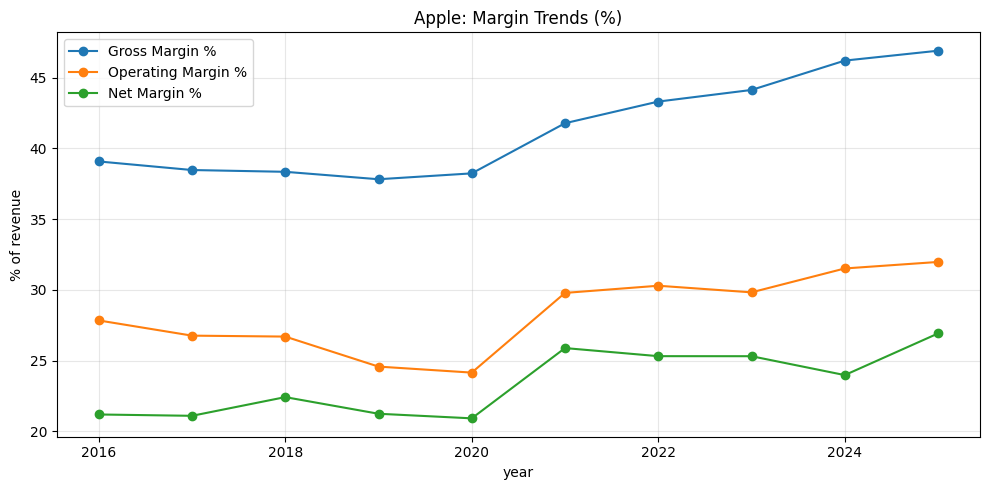

In [18]:
# ---- Analysis, Cell C: run, report, export ----
def evaluate(year):
    r = full.loc[year]
    hits = []
    for kind, category, title, test, detail in RULES:
        try:
            triggered = bool(test(r))
        except Exception:
            triggered = False  # missing data -> rule skipped
        if triggered:
            hits.append({"Year": year, "Type": kind, "Category": category,
                         "Signal": title, "Detail": detail(r)})
    return hits

COLS = ["Year", "Type", "Category", "Signal", "Detail"]
flags = pd.DataFrame([h for y in full.index[-5:] for h in evaluate(y)], columns=COLS)

def print_report(year):
    f = flags[flags["Year"] == year]
    print(f"\n===== FUNDAMENTAL ANALYSIS: FY{year} =====")
    for kind, icon, label in [("green", "✅", "GREEN FLAGS"), ("red", "🚩", "RED FLAGS")]:
        sub = f[f["Type"] == kind]
        print(f"\n{label} ({len(sub)})")
        if sub.empty:
            print("  none")
        for _, row in sub.iterrows():
            print(f"  {icon} [{row['Category']}] {row['Signal']} -> {row['Detail']}")

print_report(full.index.max())

# Flag count per year
summary = (flags.groupby(["Year", "Type"]).size().unstack(fill_value=0)
           .reindex(index=full.index[-5:], columns=["green", "red"], fill_value=0))
display(summary)

# Margin trend chart
m[["Gross Margin %", "Operating Margin %", "Net Margin %"]].iloc[-10:].plot(marker="o", figsize=(10, 5))
plt.title("Apple: Margin Trends (%)")
plt.ylabel("% of revenue")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("apple_margin_trends.png", dpi=150)
plt.show()

# Exports
flags.to_csv("apple_flags.csv", index=False)
m.round(2).to_csv("apple_metrics.csv")